# Cat Breed Classifier (CNN)

### Importing the libraries

In [1]:
import os
import random

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.metrics import accuracy_score, classification_report, f1_score, ConfusionMatrixDisplay

In [2]:
torch.__version__

'2.14.0'

### Setting the seed (for reproducibility)

In [ ]:
SEED = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # no-op on my machine (no CUDA) but doesn't affect it
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

# forcing CPU instead of MPS as in PyTorch's docs note GPU ops aren't guaranteed
# bit-for-bit deterministic the way CPU ops are, and reproducibility matters here
device = torch.device("cpu")
print("using device:", device)

using device: cpu


## Part 1 - Data Preprocessing

In [ ]:
DATA_DIR = "cat-breed"
TRAIN_DIR = os.path.join(DATA_DIR, "TRAIN")
TEST_DIR = os.path.join(DATA_DIR, "TEST")

IMG_SIZE = 64  # small on purpose as it makes the training fast on CPU
BATCH_SIZE = 32
VAL_SPLIT = 0.2  # carving 20% off the training folder for validation, since TRAIN/TEST is all we're given

### Preprocessing the training set

In [5]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=0, shear=10, scale=(0.8, 1.2)),  # ~ shear_range=0.2, zoom_range=0.2
    transforms.ToTensor(),  # also scales pixels to [0, 1], same as rescale=1./255
])

### Preprocessing the validation and test sets

In [6]:
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

### Loading the data + splitting off a validation set

In [ ]:
# loading TRAIN twice. Once with augmentation for the actual training subset,
# once plain for the validation subset (don't want val getting random-augmented images)
train_data_augmented = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
train_data_plain = datasets.ImageFolder(TRAIN_DIR, transform=eval_transform)

class_names = train_data_augmented.classes
print("classes:", class_names)

num_samples = len(train_data_augmented)
indices = list(range(num_samples))
random.Random(SEED).shuffle(indices)

val_size = int(num_samples * VAL_SPLIT)
val_indices = indices[:val_size]
train_indices = indices[val_size:]

train_dataset = Subset(train_data_augmented, train_indices)
val_dataset = Subset(train_data_plain, val_indices)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=eval_transform)

print(f"train: {len(train_dataset)}, val: {len(val_dataset)}, test: {len(test_dataset)}")

classes: ['americanshorthair', 'bengal', 'mainecoon', 'ragdoll', 'scottishfold', 'sphinx']
train: 960, val: 240, test: 300


In [8]:
loader_generator = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=loader_generator)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

### Quick sanity check on the data

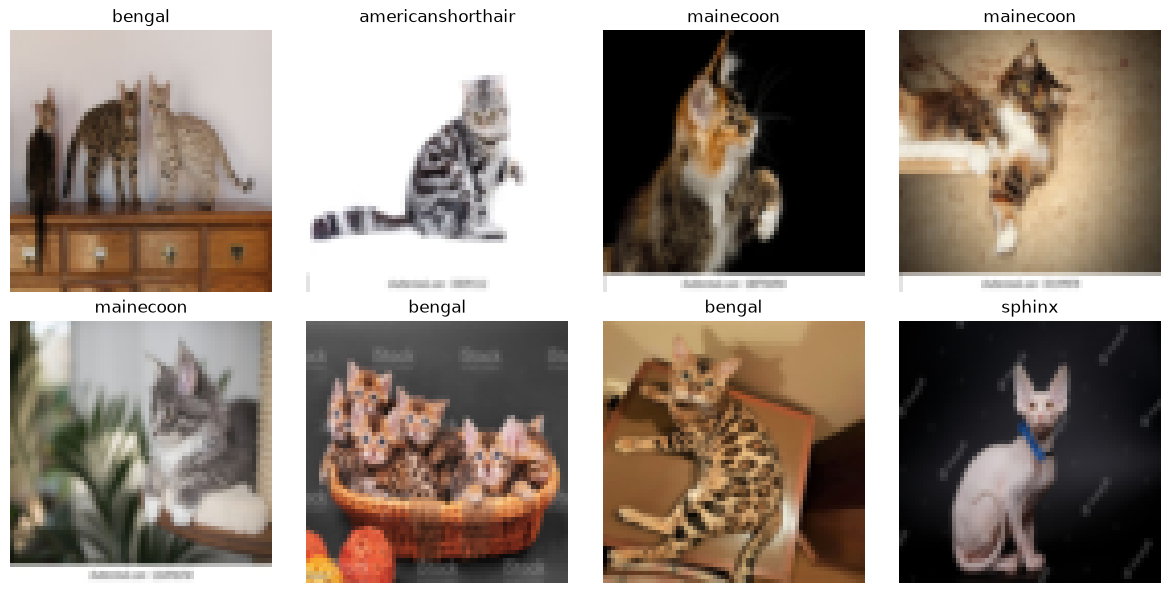

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
random.seed(SEED)
sample_idx = random.sample(range(len(train_data_plain)), 8)

for ax, idx in zip(axes.flat, sample_idx):
    img, label = train_data_plain[idx]
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(class_names[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

## Part 2 - Building the CNN

In [10]:
class CatBreedCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # Step 1 - Convolution, Step 2 - Pooling
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Adding a second convolutional layer
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()

        # working out the flattened size by running a dummy image through the conv layers
        with torch.no_grad():
            dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE)
            dummy = self.pool1(self.relu(self.conv1(dummy)))
            dummy = self.pool2(self.relu(self.conv2(dummy)))
            flattened_size = dummy.numel()

        # Step 3/4 - Flattening + Full connection
        self.fc1 = nn.Linear(flattened_size, 128)
        # Step 5 - Output layer, one unit per breed (softmax is handled inside CrossEntropyLoss)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu(self.conv1(x)))
        x = self.pool2(self.relu(self.conv2(x)))
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x


model = CatBreedCNN(num_classes=len(class_names)).to(device)
model

CatBreedCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=6272, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=6, bias=True)
)

## Part 3 - Training the CNN

In [11]:
criterion = nn.CrossEntropyLoss()  # softmax + cross-entropy combined, no softmax needed in the model
optimizer = optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 40

In [ ]:
def run_epoch(loader, training):
    # train mode turns dropout/batchnorm-type layers on, eval turns them off -
    # doesn't actually matter for this model since it has neither, but good habit
    model.train() if training else model.eval()

    running_loss = 0.0
    running_correct = 0

    # no point building the backward graph when we're just validating
    context = torch.enable_grad() if training else torch.no_grad()
    with context:
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            if training:
                optimizer.zero_grad()  # otherwise gradients pile up across batches

            outputs = model(images)
            loss = criterion(outputs, labels)

            if training:
                loss.backward()
                optimizer.step()

            # loss.item() is the average over the batch, so multiplying back by the batch size before summing keeps this a correct average once divided below
            running_loss += loss.item() * images.size(0)
            running_correct += (outputs.argmax(dim=1) == labels).sum().item()

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = running_correct / len(loader.dataset)
    return epoch_loss, epoch_acc


history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(EPOCHS):
    train_loss, train_acc = run_epoch(train_loader, training=True)
    val_loss, val_acc = run_epoch(val_loader, training=False)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch + 1}/{EPOCHS} - loss: {train_loss:.4f} - accuracy: {train_acc:.4f} "
          f"- val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.4f}")

Epoch 1/40 - loss: 1.7641 - accuracy: 0.2219 - val_loss: 1.7143 - val_accuracy: 0.2375
Epoch 2/40 - loss: 1.6701 - accuracy: 0.2844 - val_loss: 1.5956 - val_accuracy: 0.3583
Epoch 3/40 - loss: 1.5794 - accuracy: 0.3573 - val_loss: 1.5386 - val_accuracy: 0.4042
Epoch 4/40 - loss: 1.4876 - accuracy: 0.4010 - val_loss: 1.4987 - val_accuracy: 0.4292
Epoch 5/40 - loss: 1.4142 - accuracy: 0.4344 - val_loss: 1.4736 - val_accuracy: 0.4292
Epoch 6/40 - loss: 1.3821 - accuracy: 0.4542 - val_loss: 1.4445 - val_accuracy: 0.4292
Epoch 7/40 - loss: 1.3088 - accuracy: 0.5052 - val_loss: 1.4884 - val_accuracy: 0.4583
Epoch 8/40 - loss: 1.2963 - accuracy: 0.4833 - val_loss: 1.4007 - val_accuracy: 0.4625
Epoch 9/40 - loss: 1.2594 - accuracy: 0.5229 - val_loss: 1.4104 - val_accuracy: 0.4583
Epoch 10/40 - loss: 1.2158 - accuracy: 0.5490 - val_loss: 1.4786 - val_accuracy: 0.4250
Epoch 11/40 - loss: 1.2034 - accuracy: 0.5510 - val_loss: 1.3827 - val_accuracy: 0.4750
Epoch 12/40 - loss: 1.1384 - accuracy: 0.

## Part 4 - Evaluating on the Test Set

In [ ]:
# this is the first time test_loader gets touched anywhere in the notebook, everything above only ever saw train/val, so this is the real "how good is it" number
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

test_accuracy = accuracy_score(all_labels, all_preds)
print(f"Test accuracy: {test_accuracy:.4f}\n")
# classification_report gives per-breed precision/recall/f1, not just one overall number
# useful since accuracy alone can hide a model that's only good at 1 or 2 breeds
print(classification_report(all_labels, all_preds, target_names=class_names))

Test accuracy: 0.4400

                   precision    recall  f1-score   support

americanshorthair       0.41      0.32      0.36        50
           bengal       0.62      0.52      0.57        50
        mainecoon       0.33      0.34      0.33        50
          ragdoll       0.43      0.60      0.50        50
     scottishfold       0.33      0.44      0.38        50
           sphinx       0.68      0.42      0.52        50

         accuracy                           0.44       300
        macro avg       0.47      0.44      0.44       300
     weighted avg       0.47      0.44      0.44       300



## Part 5 - Visualizing the Results

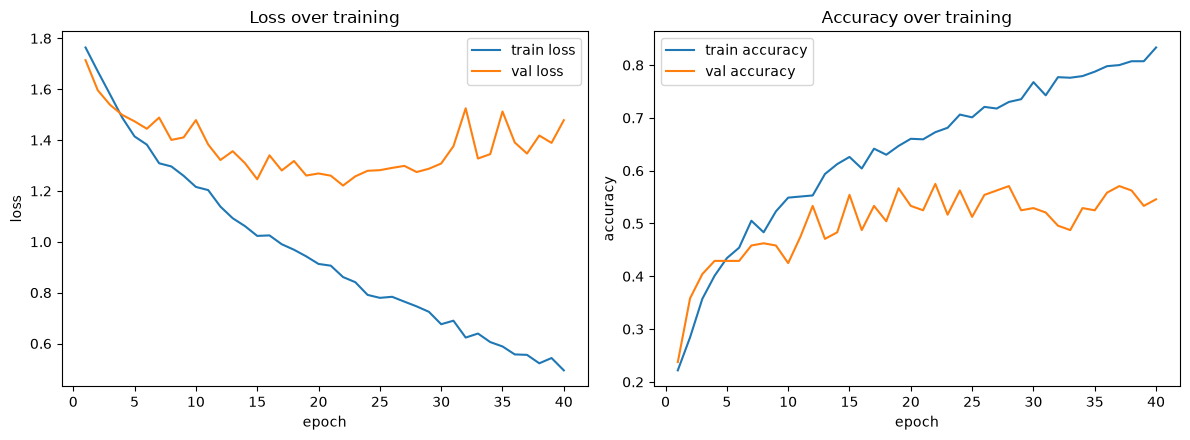

In [14]:
# mainly looking for train and val lines drifting apart - that's the classic overfitting sign
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(epochs_range, history["train_loss"], label="train loss")
axes[0].plot(epochs_range, history["val_loss"], label="val loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].set_title("Loss over training")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], label="train accuracy")
axes[1].plot(epochs_range, history["val_acc"], label="val accuracy")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].set_title("Accuracy over training")
axes[1].legend()

plt.tight_layout()
plt.show()

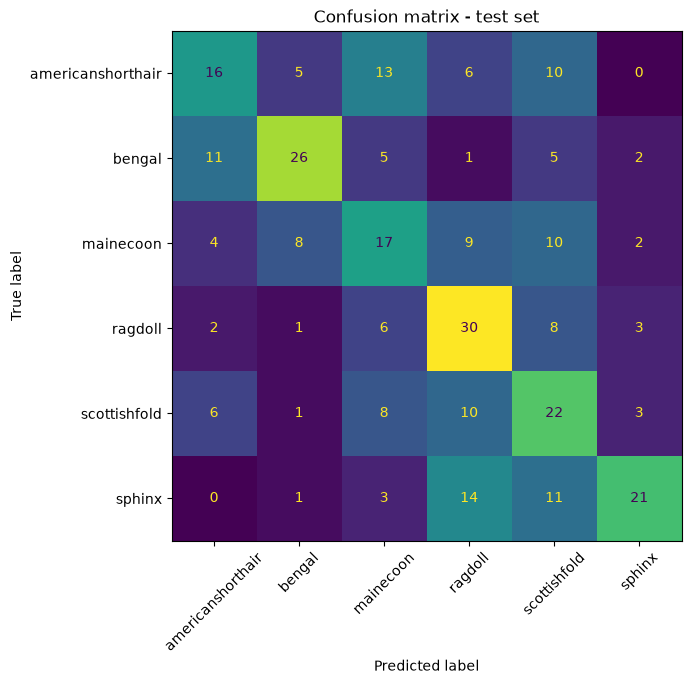

In [15]:
fig, ax = plt.subplots(figsize=(7, 7))
ConfusionMatrixDisplay.from_predictions(
    all_labels, all_preds, display_labels=class_names, xticks_rotation=45, ax=ax, colorbar=False
)
plt.title("Confusion matrix - test set")
plt.tight_layout()
plt.show()

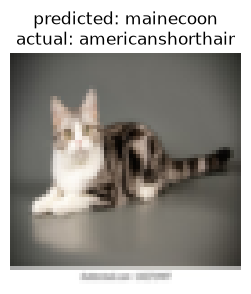

In [16]:
# grabbing one random test image and checking the prediction against the actual label
random.seed(SEED + 1)
sample_index = random.randrange(len(test_dataset))

image, true_label = test_dataset[sample_index]

model.eval()
with torch.no_grad():
    output = model(image.unsqueeze(0).to(device))
    predicted_label = output.argmax(dim=1).item()

plt.figure(figsize=(3, 3))
plt.imshow(image.permute(1, 2, 0))
plt.axis("off")
plt.title(f"predicted: {class_names[predicted_label]}\nactual: {class_names[true_label]}")
plt.show()

## Part 6 - Trying Transfer Learning

In [17]:
# my from-scratch CNN above only ever saw ~1000 training images, which isn't a lot for a
# network learning to recognize edges/textures/shapes completely from zero. a pretrained
# ImageNet model has already seen ~1.2 million images, so instead of training convolution
# layers from scratch, I'm reusing a pretrained ResNet18 as a frozen feature extractor and
# just training a small classifier head on top of its features

# python.org's build of python doesn't ship a proper CA bundle, so downloading the
# pretrained weights fails with an SSL error unless I point it at certifi's bundle instead
import certifi
os.environ.setdefault("SSL_CERT_FILE", certifi.where())

from torchvision.models import resnet18, ResNet18_Weights

In [18]:
# ResNet expects 224x224 inputs normalized with ImageNet's mean/std, not the 64x64 + plain
# rescale I used for my own CNN, so this needs its own transform
resnet_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

resnet_train_data = datasets.ImageFolder(TRAIN_DIR, transform=resnet_transform)
resnet_test_data = datasets.ImageFolder(TEST_DIR, transform=resnet_transform)

# reusing the exact same train/val split as before (same indices), just from this new dataset
resnet_train_subset = Subset(resnet_train_data, train_indices)
resnet_val_subset = Subset(resnet_train_data, val_indices)

resnet_train_loader = DataLoader(resnet_train_subset, batch_size=BATCH_SIZE, shuffle=False)
resnet_val_loader = DataLoader(resnet_val_subset, batch_size=BATCH_SIZE, shuffle=False)
resnet_test_loader = DataLoader(resnet_test_data, batch_size=BATCH_SIZE, shuffle=False)

In [19]:
backbone = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
backbone.fc = nn.Identity()  # chopping off the 1000-class ImageNet head, keeping the 512-dim features
backbone.eval()
for param in backbone.parameters():
    param.requires_grad = False  # freezing it - only the new head gets trained
backbone = backbone.to(device)

In [20]:
# running every image through the frozen backbone once and caching the resulting features,
# instead of redoing this forward pass every epoch
def extract_resnet_features(loader):
    feats, labels = [], []
    with torch.no_grad():
        for images, y in loader:
            images = images.to(device)
            out = backbone(images)
            feats.append(out.cpu().numpy())
            labels.append(y.numpy())
    return np.concatenate(feats), np.concatenate(labels)

X_train_feats, y_train_feats = extract_resnet_features(resnet_train_loader)
X_val_feats, y_val_feats = extract_resnet_features(resnet_val_loader)
X_test_feats, y_test_feats = extract_resnet_features(resnet_test_loader)

print("train:", X_train_feats.shape, "val:", X_val_feats.shape, "test:", X_test_feats.shape)

train: (960, 512) val: (240, 512) test: (300, 512)


In [21]:
X_train_feats_t = torch.tensor(X_train_feats, dtype=torch.float32)
y_train_feats_t = torch.tensor(y_train_feats, dtype=torch.long)
X_val_feats_t = torch.tensor(X_val_feats, dtype=torch.float32)
y_val_feats_t = torch.tensor(y_val_feats, dtype=torch.long)

# small MLP head on top of the frozen 512-dim ResNet features
head = nn.Sequential(
    nn.Linear(512, 128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, len(class_names)),
).to(device)

head_criterion = nn.CrossEntropyLoss()
head_optimizer = optim.Adam(head.parameters(), lr=0.001)
HEAD_EPOCHS = 60

# the whole feature set easily fits in memory, so no need for batching/DataLoaders here -
# just training on the full set each "epoch"
head_history = {"train_loss": [], "val_loss": [], "val_acc": []}
for epoch in range(HEAD_EPOCHS):
    head.train()
    head_optimizer.zero_grad()
    out = head(X_train_feats_t)
    loss = head_criterion(out, y_train_feats_t)
    loss.backward()
    head_optimizer.step()

    head.eval()
    with torch.no_grad():
        val_out = head(X_val_feats_t)
        val_loss = head_criterion(val_out, y_val_feats_t)
        val_acc = (val_out.argmax(dim=1) == y_val_feats_t).float().mean().item()

    head_history["train_loss"].append(loss.item())
    head_history["val_loss"].append(val_loss.item())
    head_history["val_acc"].append(val_acc)

    if (epoch + 1) % 10 == 0:
        print(f"epoch {epoch + 1}/{HEAD_EPOCHS} - loss: {loss.item():.4f} "
              f"- val_loss: {val_loss.item():.4f} - val_accuracy: {val_acc:.4f}")

epoch 10/60 - loss: 0.7958 - val_loss: 0.7149 - val_accuracy: 0.8667
epoch 20/60 - loss: 0.3791 - val_loss: 0.3576 - val_accuracy: 0.9250
epoch 30/60 - loss: 0.2445 - val_loss: 0.2645 - val_accuracy: 0.9250
epoch 40/60 - loss: 0.1872 - val_loss: 0.2404 - val_accuracy: 0.9292
epoch 50/60 - loss: 0.1580 - val_loss: 0.2397 - val_accuracy: 0.9250
epoch 60/60 - loss: 0.1262 - val_loss: 0.2374 - val_accuracy: 0.9250


In [22]:
head.eval()
with torch.no_grad():
    resnet_test_outputs = head(torch.tensor(X_test_feats, dtype=torch.float32))
    resnet_test_preds = resnet_test_outputs.argmax(dim=1).numpy()

resnet_test_accuracy = accuracy_score(y_test_feats, resnet_test_preds)
resnet_macro_f1 = f1_score(y_test_feats, resnet_test_preds, average="macro")

print(f"Transfer learning test accuracy: {resnet_test_accuracy:.4f}")
print(f"Transfer learning macro F1: {resnet_macro_f1:.4f}\n")
print(classification_report(y_test_feats, resnet_test_preds, target_names=class_names))
print(f"for comparison, the from-scratch CNN got: {test_accuracy:.4f} accuracy")

Transfer learning test accuracy: 0.9233
Transfer learning macro F1: 0.9233

                   precision    recall  f1-score   support

americanshorthair       0.84      0.84      0.84        50
           bengal       0.96      0.90      0.93        50
        mainecoon       0.92      0.88      0.90        50
          ragdoll       0.94      0.98      0.96        50
     scottishfold       0.89      0.96      0.92        50
           sphinx       1.00      0.98      0.99        50

         accuracy                           0.92       300
        macro avg       0.92      0.92      0.92       300
     weighted avg       0.92      0.92      0.92       300

for comparison, the from-scratch CNN got: 0.4400 accuracy


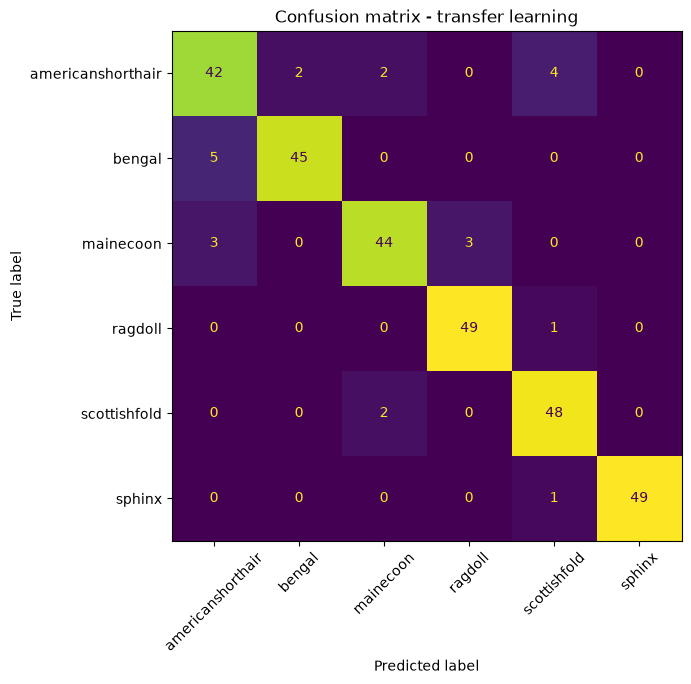

In [23]:
fig, ax = plt.subplots(figsize=(7, 7))
ConfusionMatrixDisplay.from_predictions(
    y_test_feats, resnet_test_preds, display_labels=class_names, xticks_rotation=45, ax=ax, colorbar=False
)
plt.title("Confusion matrix - transfer learning")
plt.tight_layout()
plt.show()